# Tytuł

About

1.  **Fixed acidity** – Kwasowość stała (związana z kwasami, które naturalnie występują w winogronach i nie odparowują).
2.  **Volatile acidity** – Kwasowość lotna (jej nadmiar nadaje winu nieprzyjemny, octowy posmak).
3.  **Citric acid** – Kwas cytrynowy.
4.  **Residual sugar** – Cukier resztkowy (ilość cukru, która pozostaje w winie po zakończeniu fermentacji).
5.  **Chlorides** – Chlorki (określają poziom soli w winie).
6.  **Free sulfur dioxide** – Wolny dwutlenek siarki.
7.  **Total sulfur dioxide** – Całkowity dwutlenek siarki.
8.  **Density** – Gęstość (zależy od zawartości alkoholu i cukru).
9.  **pH** – Mierzy kwasowość wina (większość win na świecie mieści się w przedziale 3.0 – 4.0).
10. **Sulphates** – Siarczany (dodatki, które mogą zwiększać poziom wolnego dwutlenku siarki).
11. **Alcohol** – Zawartość alkoholu w procentach.
12. **Quality** - Ocena jakości wina (skala od 3 do 8, gdzie 3 oznacza najgorsze, a 8 najlepsze wino).
13. **Quality_bin** - Binarna ocena jakości wina. 0 - słabe (quality<7), 1 - dobre (quality>=7).

# EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.helpers import create_percentage_plot, quality_based_plot

In [2]:
df = pd.read_csv("data/winequality-red.csv", sep=";")

In [3]:
# Dodanie kolumny do binaryzacji
df['quality_bin'] = np.astype((df['quality'] >= 7).to_numpy(), np.int8)

## Ogólne informacje

In [4]:
df.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5,0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5,0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6,0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5,0


In [5]:
df.shape

(1599, 13)

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 13 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
 12  quality_bin           1599 non-null   int8   
dtypes: float64(11), int64(1), int8(1)
memory usage: 151.6 KB


In [7]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
fixed acidity,1599.0,8.319637,1.741096,4.60000,7.1000,7.90000,9.200000,15.90000
volatile acidity,1599.0,0.527821,0.179060,0.12000,0.3900,0.52000,0.640000,1.58000
citric acid,1599.0,0.270976,0.194801,0.00000,0.0900,0.26000,0.420000,1.00000
residual sugar,1599.0,2.538806,1.409928,0.90000,1.9000,2.20000,2.600000,15.50000
chlorides,1599.0,0.087467,0.047065,0.01200,0.0700,0.07900,0.090000,0.61100
free sulfur dioxide,1599.0,15.874922,10.460157,1.00000,7.0000,14.00000,21.000000,72.00000
total sulfur dioxide,1599.0,46.467792,32.895324,6.00000,22.0000,38.00000,62.000000,289.00000
density,1599.0,0.996747,0.001887,0.99007,0.9956,0.99675,0.997835,1.00369
pH,1599.0,3.311113,0.154386,2.74000,3.2100,3.31000,3.400000,4.01000
sulphates,1599.0,0.658149,0.169507,0.33000,0.5500,0.62000,0.730000,2.00000


Poniżej widać, że nie mamy żadnych brakujących danych.

In [8]:
df.isna().sum()

fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
quality_bin             0
dtype: int64

<Axes: >

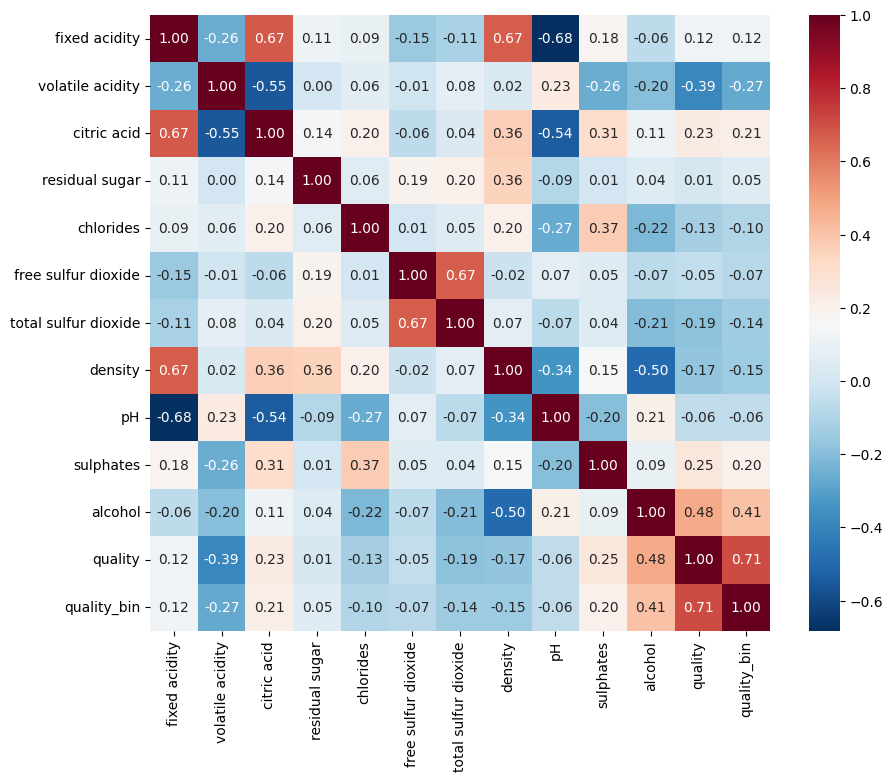

In [9]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='RdBu_r')

## quality

In [10]:
df['quality'].sort_values().unique()

array([3, 4, 5, 6, 7, 8])

Dane są drastycznie niezbalansowane.

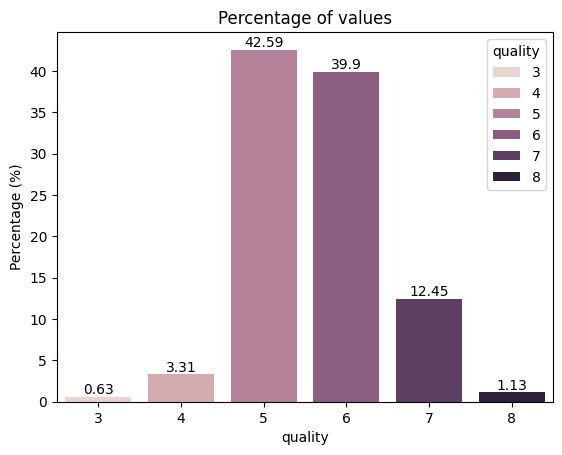

In [11]:
create_percentage_plot(df['quality'], bar_label=True)

<Axes: >

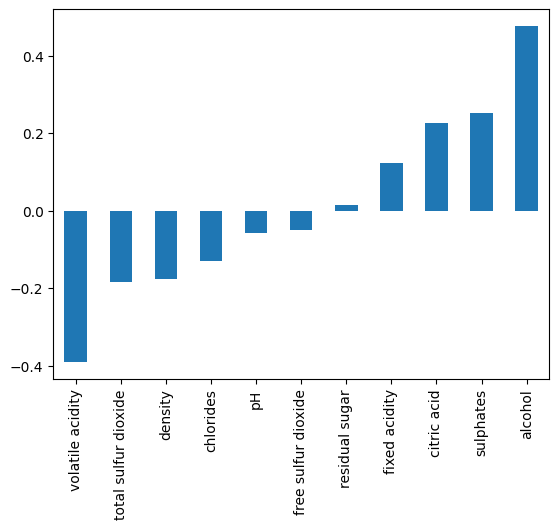

In [12]:
df.drop(['quality_bin'], axis=1).corr()['quality'][:-1].sort_values().plot(kind='bar')

Text(0.5, 1.0, 'Outliers')

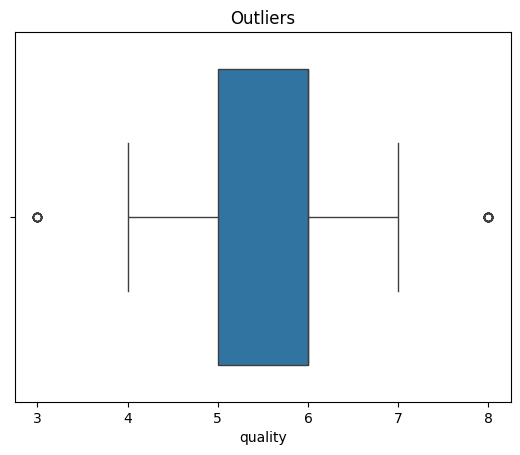

In [13]:
sns.boxplot(df, x='quality')
plt.title("Outliers")

## quality_bin

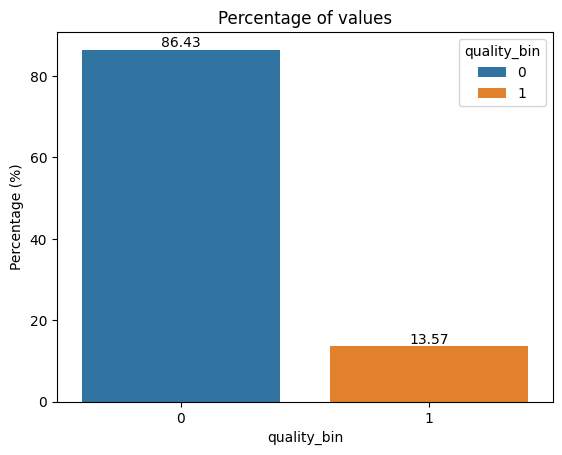

In [14]:
create_percentage_plot(df['quality_bin'], bar_label=True)

<Axes: >

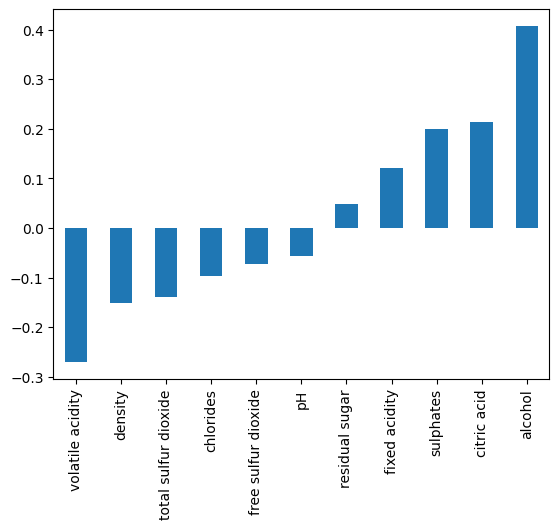

In [15]:
df.drop(['quality'], axis=1).corr()['quality_bin'][:-1].sort_values().plot(kind='bar')

## fixed acidity

Brak trendu dla tej cechy.

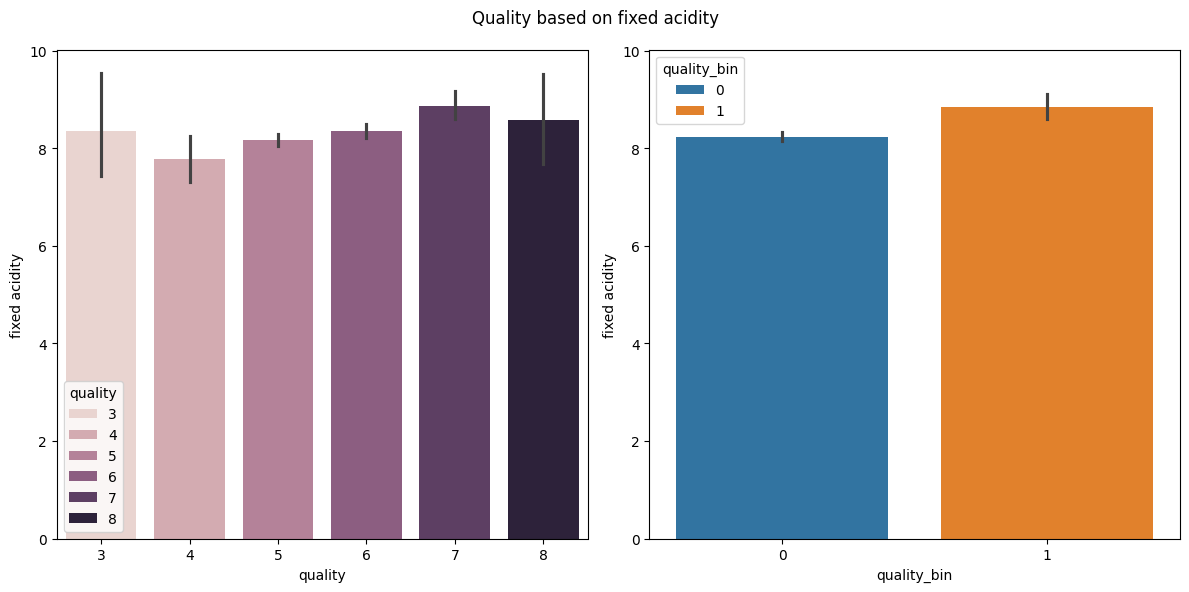

In [16]:
quality_based_plot(df, 'fixed acidity')

Poniżej widać kilka wartości odstających. W kontekście winiarskim są to naturalne wariacje produktu.

Text(0.5, 1.0, 'Outliers')

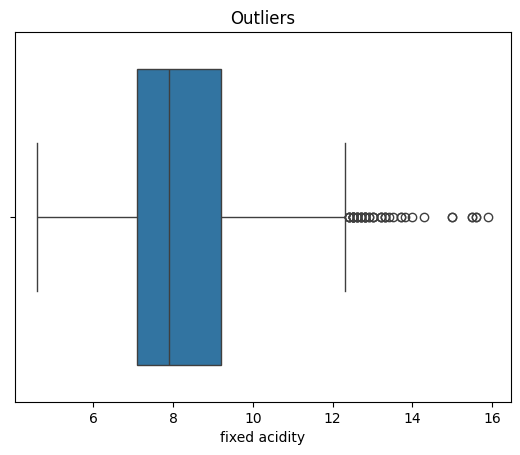

In [17]:
sns.boxplot(df, x='fixed acidity')
plt.title("Outliers")

In [18]:
df[df['fixed acidity']>12.5][['quality', 'quality_bin']].value_counts()

quality  quality_bin
6        0              17
5        0              11
7        1               9
8        1               1
Name: count, dtype: int64

## volatile acidity

Poniżej można zauważyć zależność między tą cechą a jakością wina. Im wyższa kwasowość lotna, tym gorsze wino.

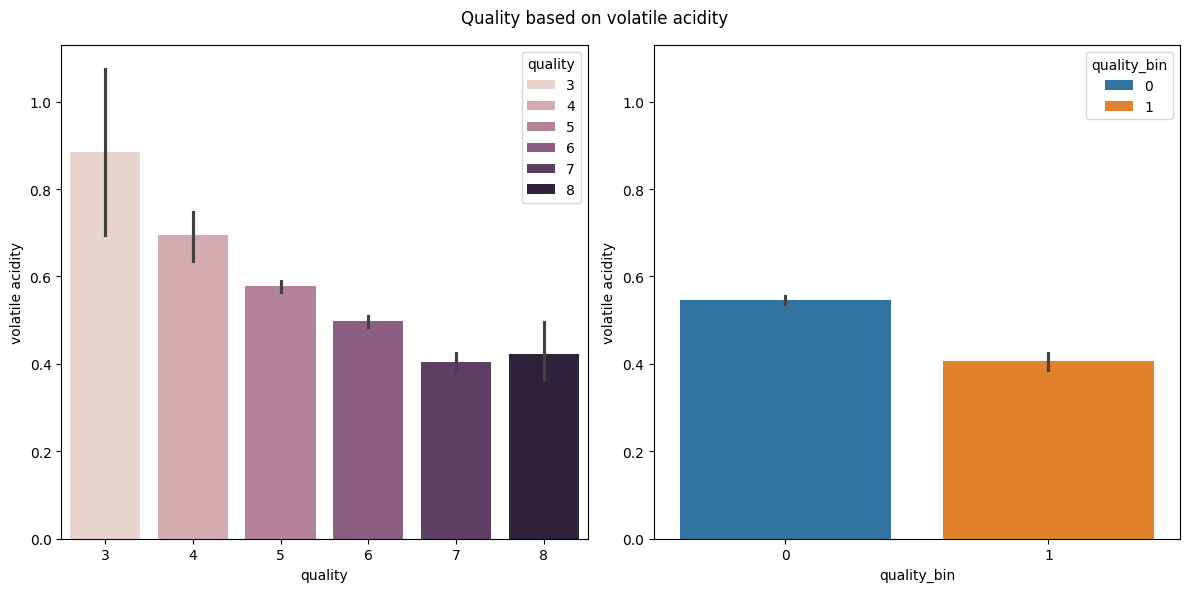

In [19]:
quality_based_plot(df, 'volatile acidity')

A podobnie jak w poprzednim wypadku, progi są akceptowalne.

Text(0.5, 1.0, 'Outliers')

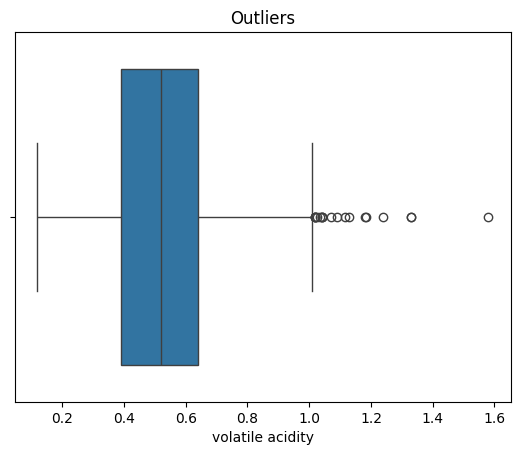

In [20]:
sns.boxplot(df, x='volatile acidity')
plt.title("Outliers")

## citric acid

Trend rosnący, im więcej kwasu cytrynowego, tym lepsze wino.

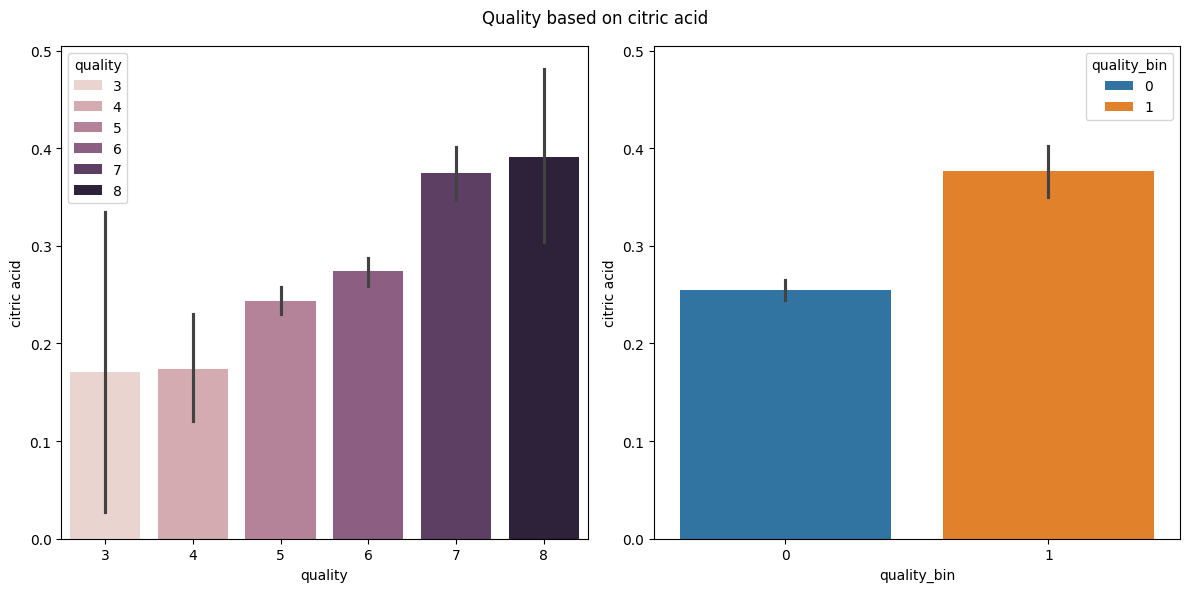

In [21]:
quality_based_plot(df, 'citric acid')

Text(0.5, 1.0, 'Outliers')

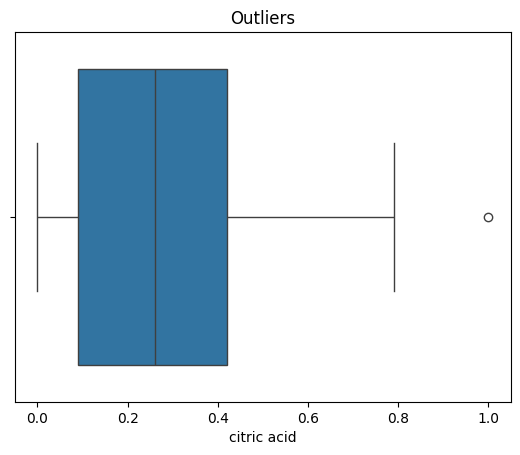

In [22]:
sns.boxplot(df, x='citric acid')
plt.title("Outliers")

## residual sugar

Brak trendu dla tej cechy.

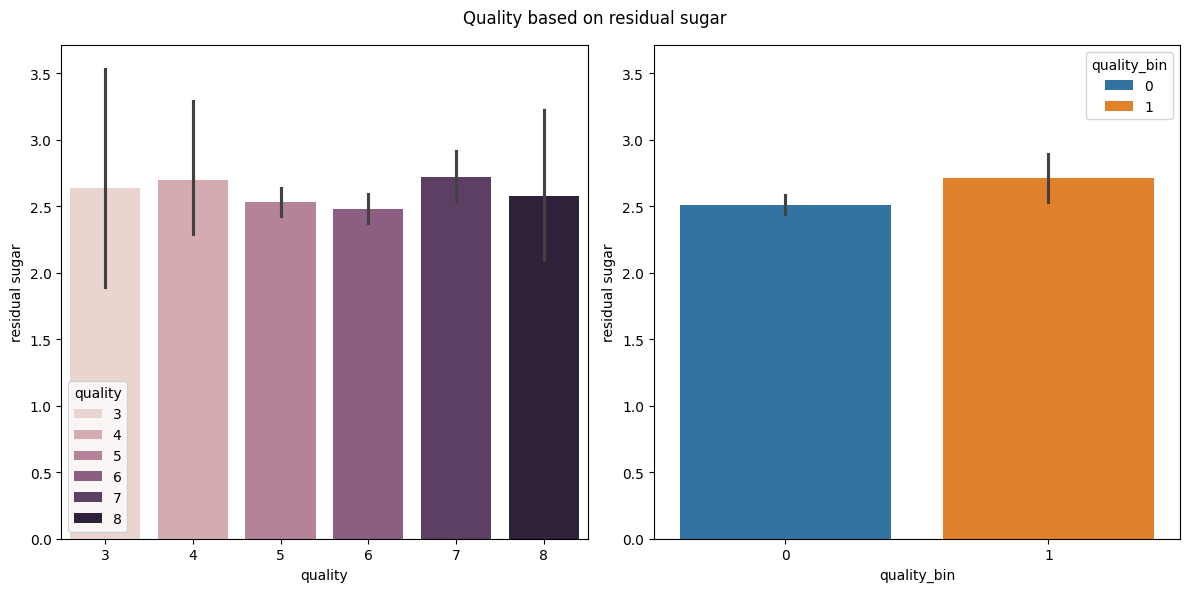

In [23]:
quality_based_plot(df, 'residual sugar')

Poniżej widać sporo wartości odstających, ale w kontekście winiarskim jest to normalne. To po prostu wina półwytrawne lub rzadsze, słodsze warianty czerwonego wina.

Text(0.5, 1.0, 'Outliers')

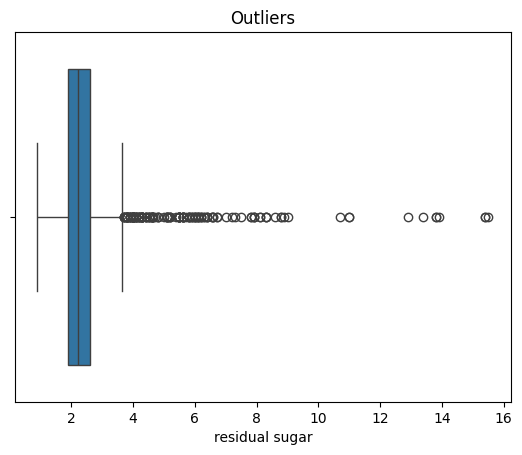

In [24]:
sns.boxplot(df, x='residual sugar')
plt.title("Outliers")

In [25]:
df[df['residual sugar']>4][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              53
6        0              36
7        1              25
4        0               7
3        0               2
8        1               2
Name: count, dtype: int64

## chlorides

Widać zależność między tą cechą a jakością wina. Im więcej chlorków, tym gorsze wino.

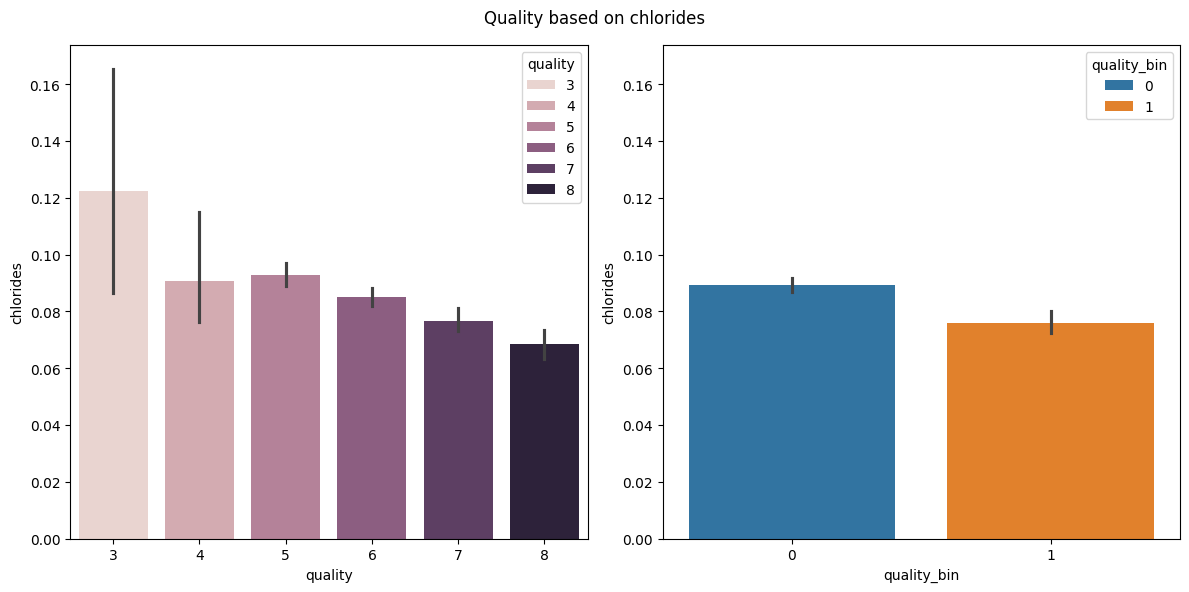

In [26]:
quality_based_plot(df, 'chlorides')

Poniżej znowu widać sporą ilość wartości odstających. Wartości te to naturalne wariacje chemiczne wina. Mogą to być wina z winnic położonych w specyficznych regionach (np. bliżej oceanu lub na glebach bogatych w minerały).

Text(0.5, 1.0, 'Outliers')

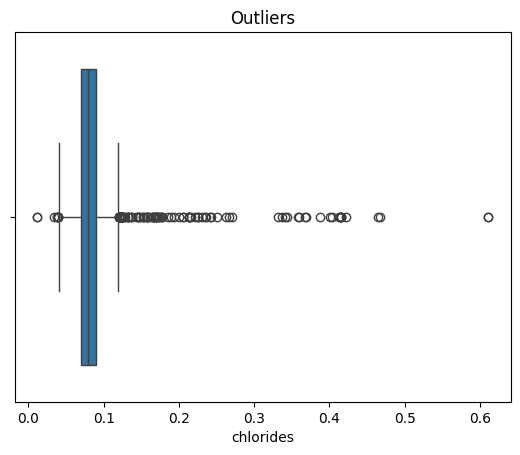

In [27]:
sns.boxplot(df, x='chlorides')
plt.title("Outliers")

In [28]:
df[df['chlorides']>0.13][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              38
6        0              30
3        0               4
4        0               3
7        1               3
Name: count, dtype: int64

## free sulfur dioxide

Brak trendu dla tej cechy.

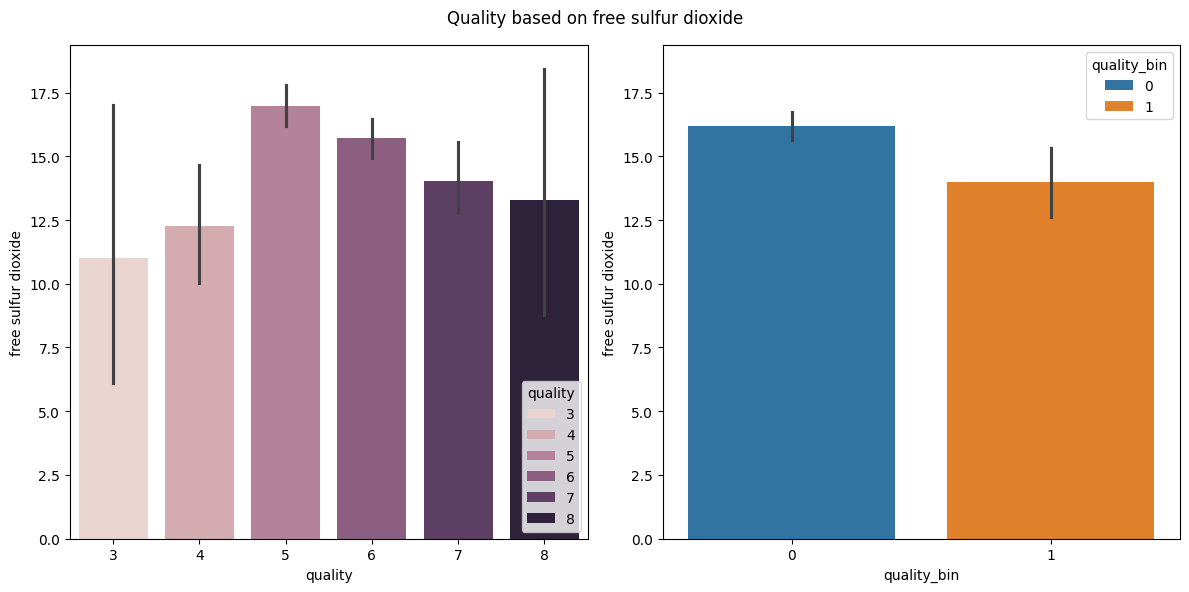

In [29]:
quality_based_plot(df, 'free sulfur dioxide')

Są to prawdziwe wartości odstające i nie jest ich dużo.

Text(0.5, 1.0, 'Outliers')

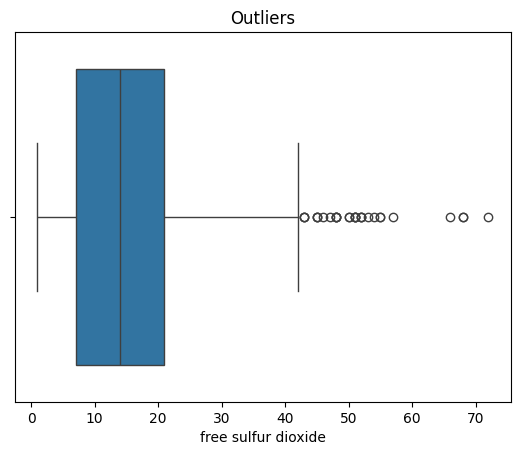

In [30]:
sns.boxplot(df, x='free sulfur dioxide')
plt.title("Outliers")

In [31]:
df[df['free sulfur dioxide']>43][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              16
6        0               7
7        1               4
Name: count, dtype: int64

## total sulfur dioxide

Podobnie, brak trendu.

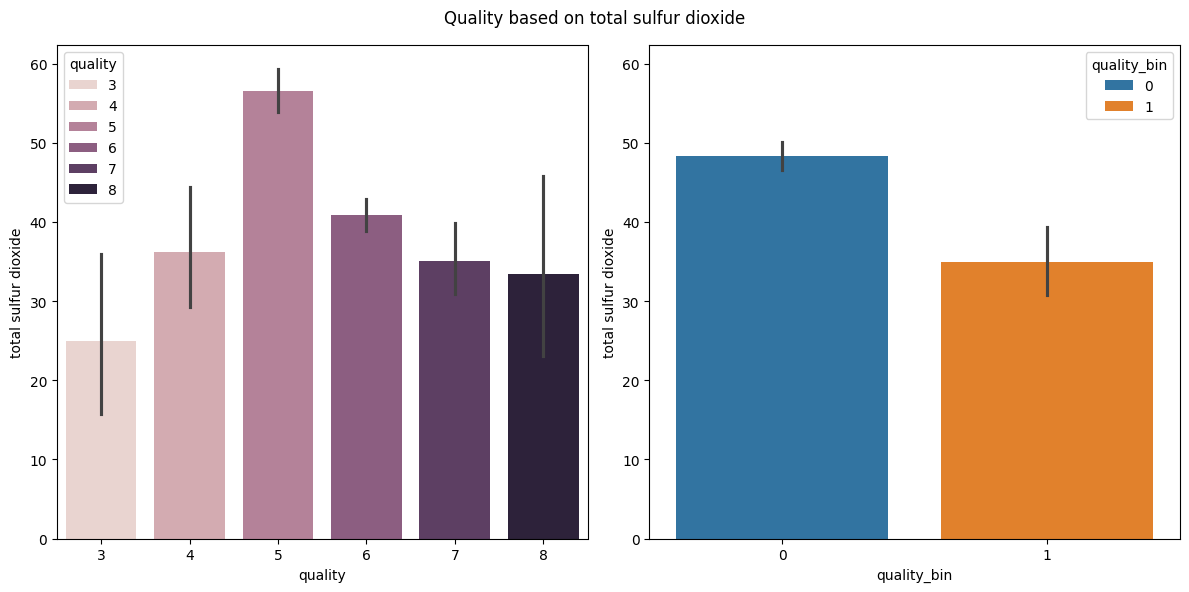

In [32]:
quality_based_plot(df, 'total sulfur dioxide')

Poniżej widać dwie skrajnie odstające wartości. Po analizie zdecydowałem je zostawić ze względu na wysoką ocenę jakości wina i na fakt, że w kontekście winiarskim takie wartości są możliwe.

Text(0.5, 1.0, 'Outliers')

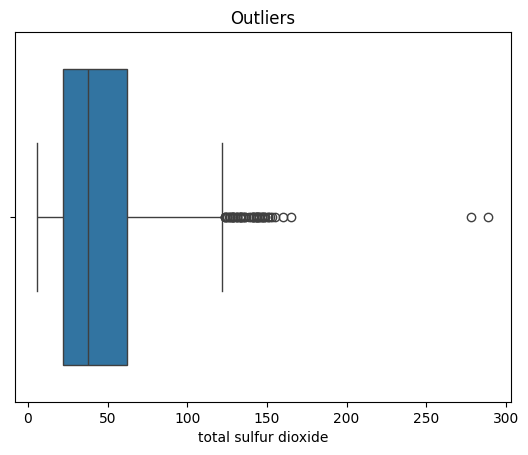

In [33]:
sns.boxplot(df, x='total sulfur dioxide')
plt.title("Outliers")

In [34]:
df[(df['total sulfur dioxide']>120) & (df['total sulfur dioxide']<200)][['quality', 'quality_bin']].value_counts()

quality  quality_bin
5        0              54
6        0               6
Name: count, dtype: int64

In [35]:
df[df['total sulfur dioxide']>250][['quality', 'quality_bin']].value_counts()

quality  quality_bin
7        1              2
Name: count, dtype: int64

In [36]:
df[df['total sulfur dioxide']>250]

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,quality_bin
1079,7.9,0.3,0.68,8.3,0.05,37.5,278.0,0.99316,3.01,0.51,12.3,7,1
1081,7.9,0.3,0.68,8.3,0.05,37.5,289.0,0.99316,3.01,0.51,12.3,7,1


## density

Wszystkie wina w zbiorze danych mają gęstość bardzo zbliżoną do 1.

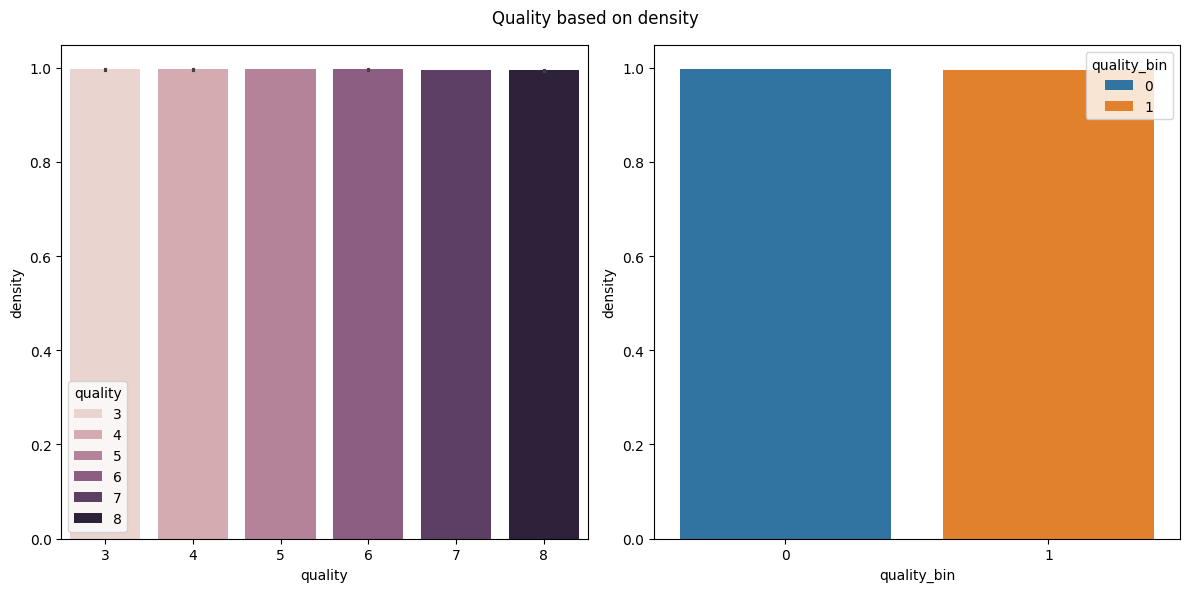

In [37]:
quality_based_plot(df, 'density')

Zbyt mikroskopijna skala żeby usuwać wartości odstające.

Text(0.5, 1.0, 'Outliers')

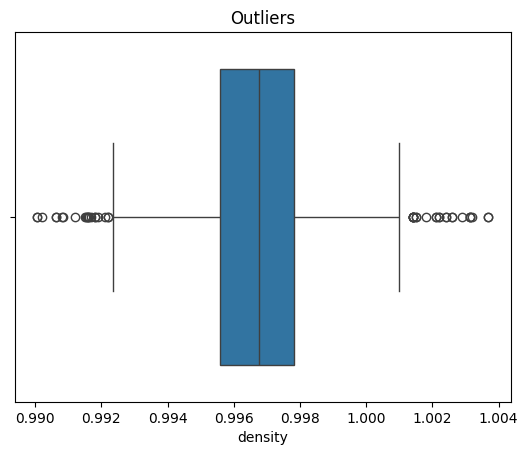

In [38]:
sns.boxplot(df, x='density')
plt.title("Outliers")

## pH

Brak większych różnic między winami o różnej jakości. Wina o wyższej jakości mają nieco niższe pH, ale różnica jest minimalna.

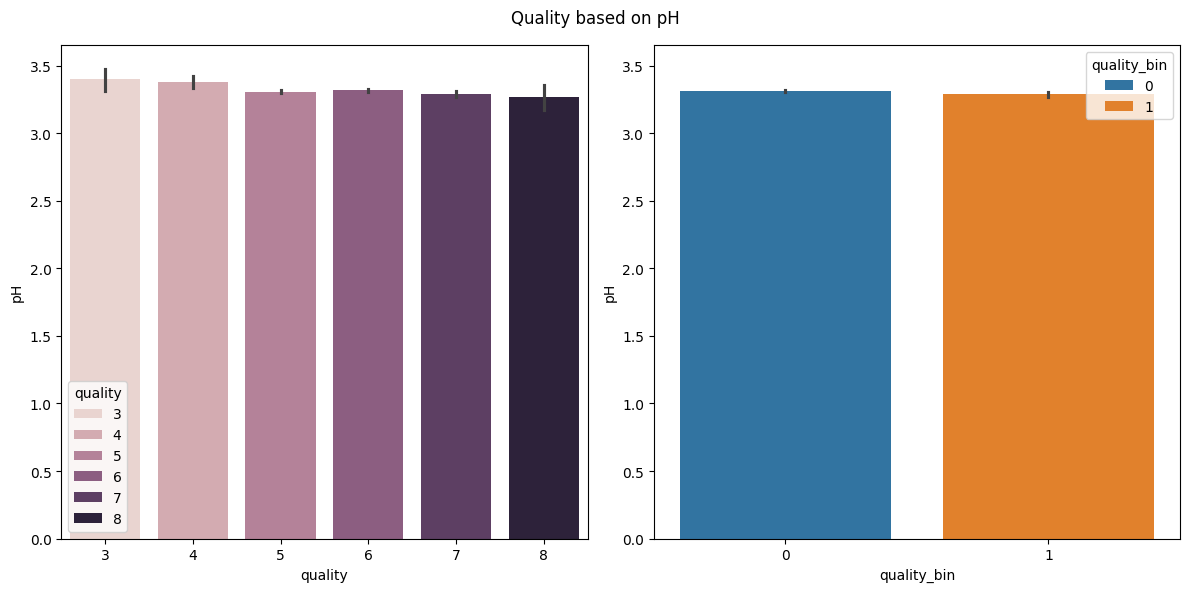

In [39]:
quality_based_plot(df, 'pH')

Nie duża liczba wartości odstających. Większość win ma pH między 3 a 4, a więc takie wartości odstające są naturalne.

Text(0.5, 1.0, 'Outliers')

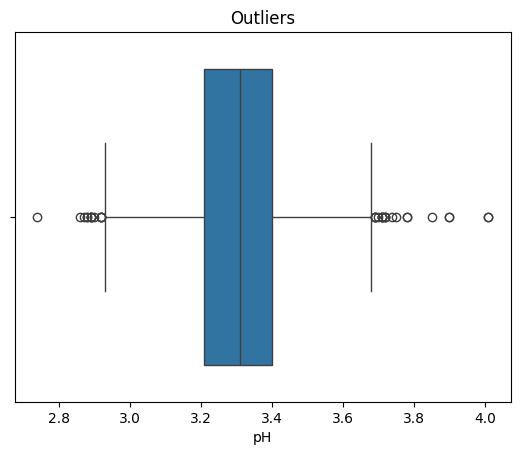

In [40]:
sns.boxplot(df, x='pH')
plt.title("Outliers")

## sulphates

Widoczny trend rosnący, im więcej siarczanów, tym lepsze wino.

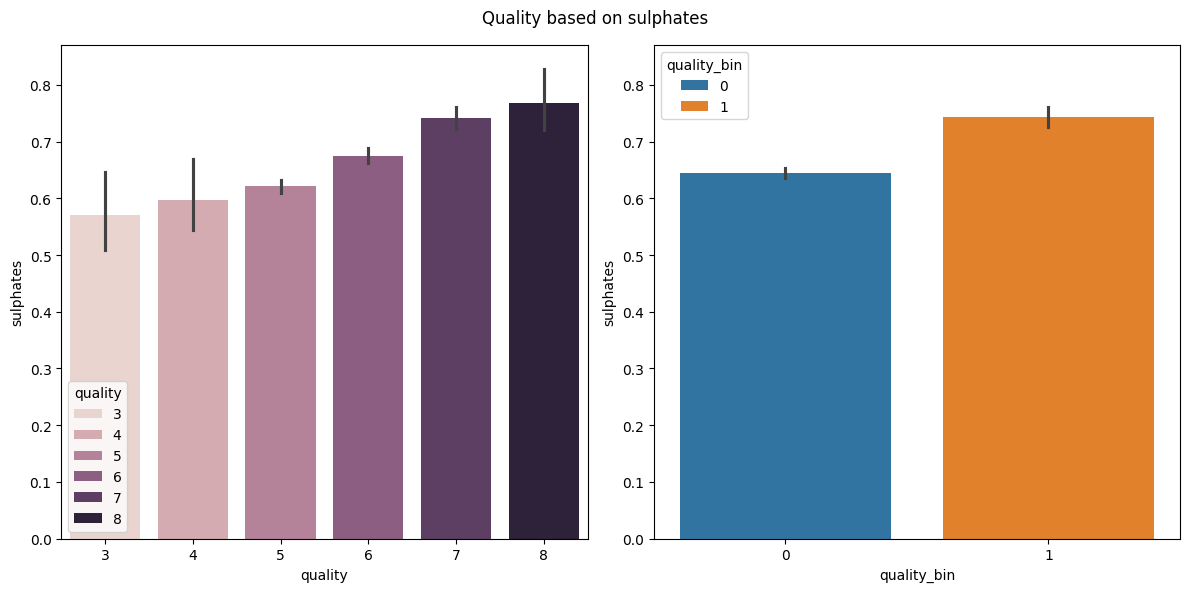

In [41]:
quality_based_plot(df, 'sulphates')

Naturalne wartości odstające, które mogą wynikać z różnych technik produkcji wina lub różnic w składzie chemicznym winogron.

Text(0.5, 1.0, 'Outliers')

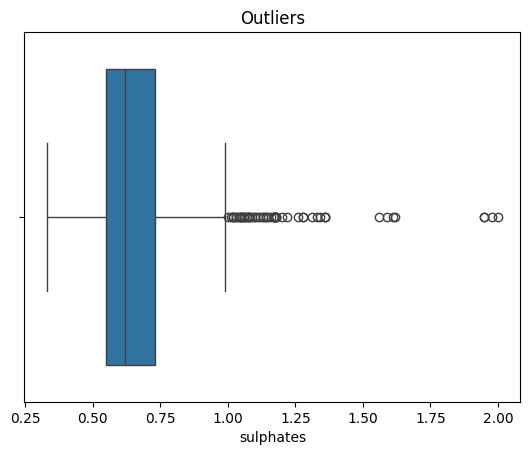

In [42]:
sns.boxplot(df, x='sulphates')
plt.title("Outliers")

## alcohol

Wina z wyższą zawartością alkoholu są oceniane jako lepsze.

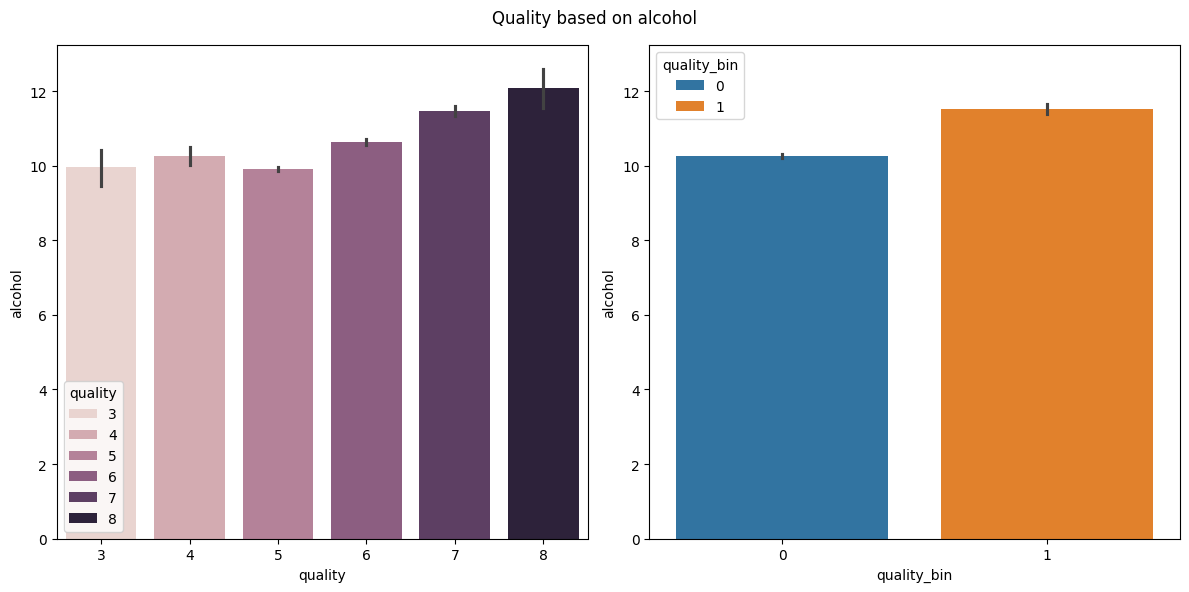

In [43]:
quality_based_plot(df, 'alcohol')

Akceptowalna liczba wartości odstających.

Text(0.5, 1.0, 'Outliers')

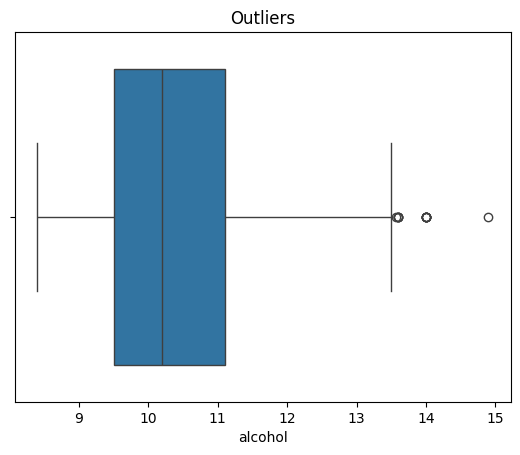

In [44]:
sns.boxplot(df, x='alcohol')
plt.title("Outliers")

## Podsumowanie EDA

Zbiór danych okazał się kompletny i pozbawiony braków (null values), co pozwoliło na płynne przejście do analizy rozkładów. W tym przypadku zostały napotkane dwa główne problemy: niezbalansowane dane oraz spora obecność wartości odstających. Niezbalansowanie danych, cechy 'quality', może prowadzić do problemów z uczeniem modelów, ponieważ mogą one być stronnicze wobec dominujących klas. Natomiast obecność naturalnych wartości odstających, które postanowiłem pozostawić ze względu na ich autentyczność w kontekście winiarskim, może być zagrożniem dla modeli opartych na odległościach, takich jak np. KNN czy SVC. Dlatego też trzeba będzie wykorzystać scaler, który jest odporny na wartości odstające, np. RobustScaler. Mimo tych problemów, analiza rozkładów pozwoliła na zidentyfikowanie kilku interesujących zależności między cechami a jakością wina, co może być cenne przy budowie modeli predykcyjnych.

# Prepocessing

In [16]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

In [17]:
X = df.drop(['quality', 'quality_bin'], axis=1)
y = df['quality']
y_bin = df['quality_bin']

In [18]:
X_train, X_test, y_train, y_test, y_train_bin, y_test_bin = train_test_split(X, y, y_bin, test_size=0.2, random_state=42, stratify=y)

In [19]:
robust_scaler = RobustScaler()

In [20]:
#X_scaled = robust_scaler.transform(X)
X_train_scaled = robust_scaler.fit_transform(X_train)
X_test_scaled = robust_scaler.transform(X_test)

# Trenowanie modeli

In [21]:
import joblib
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import f1_score, classification_report, make_scorer, confusion_matrix

## KNN

In [22]:
from sklearn.neighbors import KNeighborsClassifier

In [23]:
knn_param_grid = {
    'n_neighbors': np.arange(1, 20),
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan'],
    'leaf_size': [25, 30]
}

In [24]:
knn_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
    error_score='raise',
)

In [25]:
knn_grid.fit(X_train_scaled, y_train)

,estimator,KNeighborsClassifier()
,param_grid,"{'leaf_size': [25, 30], 'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 1, 2... 18, 19]), 'weights': ['uniform', 'distance']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,n_neighbors,np.int64(1)


In [26]:
knn_grid.best_params_

{'leaf_size': 25,
 'metric': 'manhattan',
 'n_neighbors': np.int64(1),
 'weights': 'uniform'}

In [27]:
knn_pred = knn_grid.predict(X_test_scaled)

In [28]:
print(classification_report(y_test, knn_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.11      0.09      0.10        11
           5       0.74      0.68      0.70       136
           6       0.64      0.62      0.63       128
           7       0.45      0.62      0.52        40
           8       0.25      0.33      0.29         3

    accuracy                           0.62       320
   macro avg       0.36      0.39      0.37       320
weighted avg       0.63      0.62      0.62       320



In [29]:
print(confusion_matrix(y_test, knn_pred))

[[ 0  1  0  1  0  0]
 [ 0  1  5  5  0  0]
 [ 0  5 92 30  8  1]
 [ 1  2 22 80 22  1]
 [ 0  0  5  9 25  1]
 [ 0  0  1  0  1  1]]


In [30]:
knn_final = KNeighborsClassifier(**knn_grid.best_params_)

In [31]:
#knn_final.fit(X_scaled, y)

In [32]:
#joblib.dump(knn_final, filename="models/KNN.joblib")

### Podsumowanie

Model KNN słabo sobie radzi z wieloklasową klasyfikacją w tym zbiorze danych. Choć ogólna dokładność modelu wynosi 62%, jest to metryka złudna, silnie napędzana przez dominację klas 5 i 6. Powinniśmy tutaj trzymać się metryki macro F1, która wynosi tylko 0.37 i lepiej oddaje rzeczywistą wydajność modelu. Pokazuje ona, że gdy potraktujemy każdą klasę (nawet tę rzadką) z równą wagą, model radzi sobie słabo.

## KNN Binary

In [33]:
knn_bin_grid = GridSearchCV(
    estimator=KNeighborsClassifier(),
    param_grid=knn_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
    error_score='raise'
)

In [34]:
knn_bin_grid.fit(X_train_scaled, y_train_bin)

,estimator,KNeighborsClassifier()
,param_grid,"{'leaf_size': [25, 30], 'metric': ['euclidean', 'manhattan'], 'n_neighbors': array([ 1, 2... 18, 19]), 'weights': ['uniform', 'distance']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,'raise'
,return_train_score,False
,n_neighbors,np.int64(8)


In [35]:
knn_bin_grid.best_params_

{'leaf_size': 25,
 'metric': 'manhattan',
 'n_neighbors': np.int64(8),
 'weights': 'distance'}

In [36]:
knn_bin_pred = knn_bin_grid.predict(X_test_scaled)

In [37]:
print(classification_report(y_test_bin, knn_bin_pred))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95       277
           1       0.77      0.53      0.63        43

    accuracy                           0.92       320
   macro avg       0.85      0.75      0.79       320
weighted avg       0.91      0.92      0.91       320



In [38]:
print(confusion_matrix(y_test_bin, knn_bin_pred))

[[270   7]
 [ 20  23]]


In [39]:
knn_bin_final = KNeighborsClassifier(**knn_bin_grid.best_params_)

In [40]:
#knn_bin_final.fit(X_scaled, y_bin)

In [41]:
#joblib.dump(knn_bin_final, filename="models/KNN_bin.joblib")

### Podsumowanie

KNN w klasyfikacji binarnej poradził sobie lepiej. Wykazuje wysoką precyzję (0.77) przy jednoczesnej niskiej czułości (0.53) dla klasy mniejszościowej. Oznacza to, że algorytm jest bardzo ostrożny

## SVC

In [42]:
from sklearn.svm import SVC

In [43]:
svc_param_grid = {
    'C': [0.1, 0.5, 0.7, 1, 1.2, 2, 10, 15, 20],
    'kernel':['linear', 'rbf'],
    'class_weight': ['balanced', None],
    'gamma' :['scale', 'auto']
}

In [44]:
svc_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svc_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1,
)

In [45]:
svc_grid.fit(X_train_scaled, y_train)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 0.5, ...], 'class_weight': ['balanced', None], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [46]:
svc_grid.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

In [47]:
svc_pred = svc_grid.predict(X_test_scaled)

In [48]:
print(classification_report(y_test, svc_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.10      0.27      0.14        11
           5       0.68      0.62      0.65       136
           6       0.67      0.50      0.57       128
           7       0.49      0.70      0.58        40
           8       0.11      0.33      0.17         3

    accuracy                           0.56       320
   macro avg       0.34      0.40      0.35       320
weighted avg       0.62      0.56      0.58       320



In [49]:
print(confusion_matrix(y_test, svc_pred))

[[ 0  1  1  0  0  0]
 [ 1  3  6  1  0  0]
 [ 2 18 84 25  6  1]
 [ 1  9 31 64 21  2]
 [ 0  0  2  5 28  5]
 [ 0  0  0  0  2  1]]


In [50]:
svc_finall = SVC(**svc_grid.best_params_, random_state=42)

In [51]:
#svc_finall.fit(X_scaled, y)

In [52]:
#joblib.dump(svc_finall, filename="models/SVC.joblib")

### Podsumowanie

Wprowadzenie wag klasowych przyniosło zamierzony efekt. Zdolność modelu (Recall) do identyfikacji klas mniejszościowych drastycznie wzrosła. Model zaczął 'zauważać' wina słabe (klasa 4) oraz poprawił skuteczność w wykrywaniu win dobrych (klasa 7).

## SVC Binary

In [53]:
svc_bin_grid = GridSearchCV(
    estimator=SVC(random_state=42),
    param_grid=svc_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1,
)

In [54]:
svc_bin_grid.fit(X_train_scaled, y_train_bin)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 0.5, ...], 'class_weight': ['balanced', None], 'gamma': ['scale', 'auto'], 'kernel': ['linear', 'rbf']}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [55]:
svc_bin_grid.best_params_

{'C': 10, 'class_weight': 'balanced', 'gamma': 'auto', 'kernel': 'rbf'}

In [56]:
svc_bin_pred = svc_bin_grid.predict(X_test_scaled)

In [57]:
print(classification_report(y_test_bin, svc_bin_pred))

              precision    recall  f1-score   support

           0       0.97      0.87      0.92       277
           1       0.50      0.81      0.62        43

    accuracy                           0.87       320
   macro avg       0.73      0.84      0.77       320
weighted avg       0.91      0.87      0.88       320



In [58]:
print(confusion_matrix(y_test_bin, svc_bin_pred))

[[242  35]
 [  8  35]]


In [59]:
svc_bin_finall = SVC(**svc_bin_grid.best_params_,random_state=42)

In [60]:
#svc_bin_finall.fit(X_scaled, y_bin)

In [61]:
#joblib.dump(svc_bin_finall, filename="models/SVC_bin.joblib")

Model SVC w binarnej klasyfikacji poradził sobie bardzo dobrze. O wiele lepiej klasyfikuje klasę mniejszościową (dobre wina) niż KNN, osiągając znacznie wyższą czułość (Recall) kosztem niższej precyzji (Precision).

## Random Forest

In [62]:
from sklearn.ensemble import RandomForestClassifier

In [63]:
rf_param_grid = {
    'n_estimators': [100,700],
    'max_depth': [None, 10,],
    'min_samples_split': [10],
    'class_weight': ['balanced', 'balanced_subsample']
}


In [64]:
rf_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1_macro',
    cv=5,
    n_jobs=-1
)

In [65]:
rf_grid.fit(X_train_scaled, y_train)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [None, 10], 'min_samples_split': [10], 'n_estimators': [100, 700]}"
,scoring,'f1_macro'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,100


In [66]:
rf_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': None,
 'min_samples_split': 10,
 'n_estimators': 100}

In [67]:
rf_pred = rf_grid.predict(X_test_scaled)

In [68]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.33      0.09      0.14        11
           5       0.73      0.74      0.74       136
           6       0.63      0.70      0.67       128
           7       0.68      0.57      0.62        40
           8       0.50      0.33      0.40         3

    accuracy                           0.68       320
   macro avg       0.48      0.41      0.43       320
weighted avg       0.67      0.68      0.67       320



In [69]:
print(confusion_matrix(y_test, rf_pred))


[[  0   0   1   1   0   0]
 [  1   1   6   3   0   0]
 [  0   2 101  32   1   0]
 [  0   0  29  90   9   0]
 [  0   0   1  15  23   1]
 [  0   0   0   1   1   1]]


In [70]:
rf_final = RandomForestClassifier(**rf_grid.best_params_, random_state=42)

### Podsumowanie

Model osiągnął najwyższą dotychczasową dokładność (68%) i solidne wyniki F1 dla dominujących klas (5 i 6).Dzięki zastosowaniu `class_weight='balanced'`, model lepiej radzi sobie z identyfikacją rzadszych klas (7 i 8) w porównaniu do standardowego KNN.Macierz pomyłek pokazuje, że błędy najczęściej polegają na pomyleniu klas sąsiadujących (np. 5 z 6).

## Random Forest Binary

In [71]:
rf_bin_grid = GridSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_grid=rf_param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

In [72]:
rf_bin_grid.fit(X_train_scaled, y_train_bin)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'class_weight': ['balanced', 'balanced_subsample'], 'max_depth': [None, 10], 'min_samples_split': [10], 'n_estimators': [100, 700]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,700


In [73]:
rf_bin_grid.best_params_

{'class_weight': 'balanced',
 'max_depth': 10,
 'min_samples_split': 10,
 'n_estimators': 700}

In [74]:
rf_bin_pred = rf_bin_grid.predict(X_test_scaled)


In [75]:
print(classification_report(y_test_bin, rf_bin_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95       277
           1       0.70      0.70      0.70        43

    accuracy                           0.92       320
   macro avg       0.83      0.83      0.83       320
weighted avg       0.92      0.92      0.92       320



In [76]:
print(confusion_matrix(y_test_bin, rf_bin_pred))

[[264  13]
 [ 13  30]]


In [77]:
rf_bin_final = RandomForestClassifier(**rf_bin_grid.best_params_, random_state=42)

### Podsumowanie

Wersja binarna wykazuje bardzo dobrą równowagę między precyzją a czułością (obie na poziomie 0.70 dla dobrych win). Jest to model stabilniejszy niż SVC Binary – mimo nieco niższej czułości, rzadziej generuje fałszywe alarmy (wyższa precyzja). Analiza **Feature Importance** przybliży obraz tego które cechy mają decydujący wpływ na klasyfikację wina jako "dobre".

## Feature Importance (Ważność cech)
Analiza istotności cech dla najlepszego modelu Random Forest.

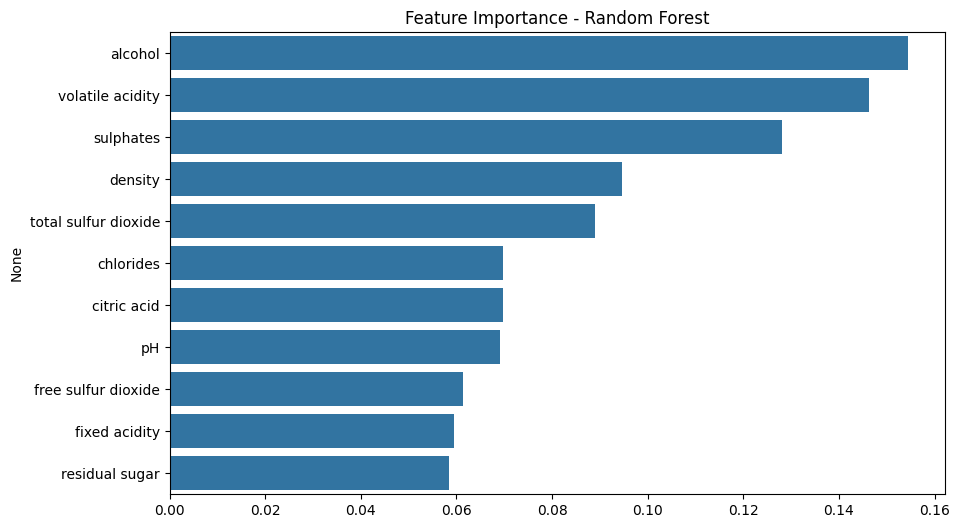

In [78]:
best_rf = rf_grid.best_estimator_
importances = pd.Series(best_rf.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest")
plt.show()

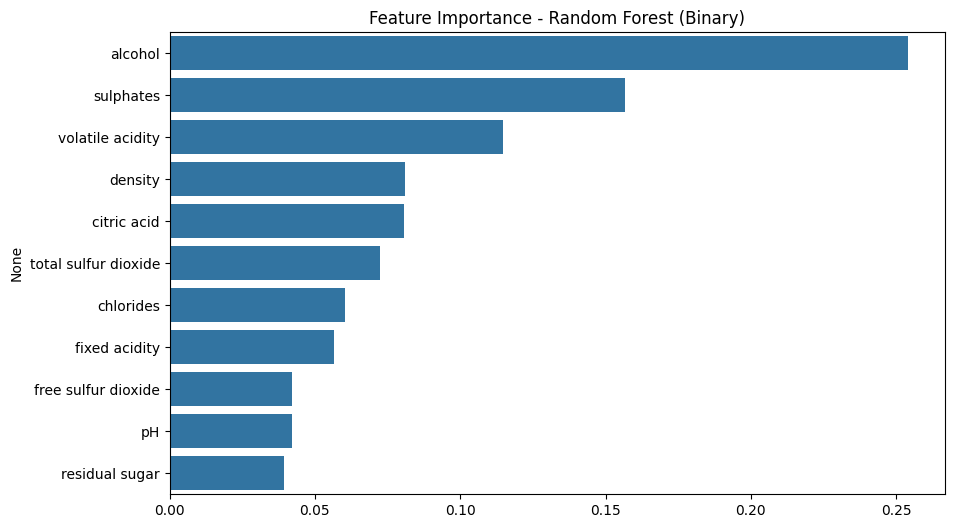

In [79]:
best_rf_bin = rf_bin_grid.best_estimator_
importances = pd.Series(best_rf_bin.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.values, y=importances.index)
plt.title("Feature Importance - Random Forest (Binary)")
plt.show()

### Wnioski z analizy istotności cech (Feature Importance)

Na podstawie rankingu cech wygenerowanego przez model Random Forest można wyciągnąć następujące wnioski:

**Kluczowa rola alkoholu**: Zawartość alkoholu (`alcohol`) jest zdecydowanie najważniejszą cechą determinującą jakość wina. Potwierdza to wcześniejsze obserwacje z etapu EDA, gdzie wyższa zawartość alkoholu korelowała z lepszymi ocenami, choć należy zauważyć, że jego wiodący wpływ jest zdecydowanie lepiej widoczny przy klasyfikacji binarnej.

**Wpływ kwasowości lotnej i siarczanów**: `volatile acidity` oraz `sulphates` zajmują kolejne miejsca. Potwierdza to chemiczną naturę jakości wina – nadmiar kwasowości lotnej (zapach octu) dyskwalifikuje wino, podczas gdy odpowiedni poziom siarczanów (konserwantów) sprzyja utrzymaniu pożądanej jakości .

## MLP

In [97]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input, BatchNormalization
from tensorflow.keras.optimizers import Adam

# Sprawdzenie dostępności GPU
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
  print('GPU nie zostało znalezione. Upewnij się, że w Runtime -> Change runtime type wybrano GPU.')
else:
  print('Znaleziono GPU w: {}'.format(device_name))

GPU nie zostało znalezione. Upewnij się, że w Runtime -> Change runtime type wybrano GPU.


In [ ]:
def create_mlp_model_bin(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()
    
    # NOWOŚĆ: Definiujemy kształt danych wejściowych za pomocą obiektu Input
    model.add(Input(shape=(input_dim,)))
    
    # Pierwsza warstwa Dense jest teraz zwykłą warstwą i nie potrzebuje input_dim
    model.add(Dense(layers[0], activation=activation))
    
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.2))
        
    model.add(Dense(1, activation='sigmoid'))

    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='binary_crossentropy', 
                  metrics=['accuracy'])
    
    return model


def create_mlp_model(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()
    model.add(Dense(layers[0], input_dim=input_dim, activation=activation))
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation=activation))
        model.add(Dropout(0.2))
    model.add(Dense(1, activation='sigmoid'))
    model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
    return model

In [99]:
# Definicja zestawów do przetestowania
architectures = [[256, 128, 64], [16,8],[32, 16], [64, 32], [128, 64, 32],[128, 64, 32,16,8]]
results = []

In [ ]:
for arch in architectures:
    print(f"Trening dla architektury: {arch}")
    model = create_mlp_model_bin(layers=arch, input_dim=X_train_scaled.shape[1])
    history = model.fit(X_train_scaled, y_train_bin, epochs=50, batch_size=32, verbose=0, validation_split=0.2)
    val_acc = max(history.history['val_accuracy'])
    results.append({'arch': arch, 'val_acc': val_acc})


Trening dla architektury: [256, 128, 64]
Trening dla architektury: [16, 8]
Trening dla architektury: [32, 16]
Trening dla architektury: [64, 32]
Trening dla architektury: [128, 64, 32]
Trening dla architektury: [128, 64, 32, 16, 8]


In [ ]:
results_df_bin = pd.DataFrame(results).sort_values(by='val_acc', ascending=False)

In [ ]:
results_df_bin

,arch,val_acc
4,"[128, 64, 32]",0.882812
5,"[128, 64, 32, 16, 8]",0.878906
0,"[256, 128, 64]",0.875000
1,"[16, 8]",0.859375
3,"[64, 32]",0.851562
2,"[32, 16]",0.847656


10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           0       0.94      0.95      0.95       277
           1       0.67      0.60      0.63        43

    accuracy                           0.91       320
   macro avg       0.80      0.78      0.79       320
weighted avg       0.90      0.91      0.90       320



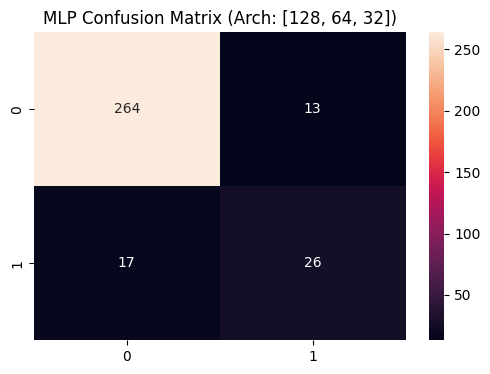

In [ ]:
best_arch = results_df_bin.iloc[0]['arch']
final_mlp = create_mlp_model_bin(layers=best_arch, input_dim=X_train_scaled.shape[1])
final_mlp.fit(X_train_scaled, y_train_bin, epochs=100, batch_size=32, verbose=0)

mlp_pred = (final_mlp.predict(X_test_scaled) > 0.5).astype("int32")
print(classification_report(y_test_bin, mlp_pred))

plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_bin, mlp_pred), annot=True, fmt='d')
plt.title(f'MLP bin Confusion Matrix (Arch: {best_arch})')
plt.show()

In [115]:
from tensorflow.keras.utils import to_categorical
from sklearn.utils.class_weight import compute_class_weight

y_train_multi = y_train - 3
y_test_multi = y_test - 3
num_classes = 6

weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(y_train_multi),
    y=y_train_multi
)

class_weights_dict = dict(enumerate(weights))

# One-hot encoding
y_train_cat = to_categorical(y_train_multi, num_classes)
y_test_cat = to_categorical(y_test_multi, num_classes)

def create_multiclass_mlp(layers=[64, 32], activation='relu', input_dim=11):
    model = Sequential()
    
    # NOWOŚĆ: Definiujemy kształt danych wejściowych za pomocą obiektu Input
    model.add(Input(shape=(input_dim,)))
    
    # Pierwsza warstwa Dense jest teraz zwykłą warstwą i nie potrzebuje input_dim
    model.add(Dense(layers[0], activation=activation))
    for neurons in layers[1:]:
        model.add(Dense(neurons, activation='relu'))
        model.add(BatchNormalization())
        model.add(Dropout(0.1))
    model.add(Dense(num_classes, activation='softmax')) # Softmax dla wielu klas
    model.compile(optimizer=Adam(learning_rate=0.001), 
                  loss='categorical_crossentropy', 
                  metrics=['accuracy'])
    return model



In [116]:
multi_architectures = [[32, 16], [64, 32], [128, 64], [256, 128, 64], [64, 64, 64]]
multi_results = []

for arch in multi_architectures:
    print(f"Testowanie architektury wieloklasowej: {arch}")
    model = create_multiclass_mlp(layers=arch, input_dim=X_train_scaled.shape[1])
    
    # Trening z podziałem na walidację i wagami klas
    history = model.fit(
        X_train_scaled, y_train_cat, 
        epochs=50, 
        batch_size=32, 
        verbose=0, 
        validation_split=0.2,
        class_weight=class_weights_dict
    )
    
    val_acc = max(history.history['val_accuracy'])
    multi_results.append({'arch': arch, 'val_acc': val_acc})

multi_results_df = pd.DataFrame(multi_results).sort_values(by='val_acc', ascending=False)
display(multi_results_df)

Testowanie architektury wieloklasowej: [32, 16]
Testowanie architektury wieloklasowej: [64, 32]
Testowanie architektury wieloklasowej: [128, 64]
Testowanie architektury wieloklasowej: [256, 128, 64]
Testowanie architektury wieloklasowej: [64, 64, 64]


,arch,val_acc
2,"[128, 64]",0.582031
3,"[256, 128, 64]",0.574219
4,"[64, 64, 64]",0.558594
1,"[64, 32]",0.503906
0,"[32, 16]",0.417969


Najlepsza wybrana architektura: [128, 64]
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 
              precision    recall  f1-score   support

           3       0.00      0.00      0.00         2
           4       0.11      0.18      0.14        11
           5       0.69      0.70      0.70       136
           6       0.65      0.53      0.58       128
           7       0.52      0.68      0.59        40
           8       0.17      0.33      0.22         3

    accuracy                           0.60       320
   macro avg       0.36      0.40      0.37       320
weighted avg       0.62      0.60      0.61       320



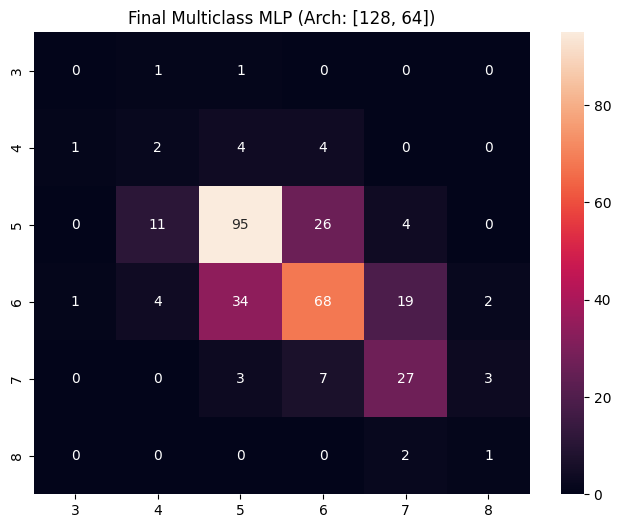

In [117]:
# Trenowanie ostatecznego modelu na najlepszej architekturze
best_multi_arch = multi_results_df.iloc[0]['arch']
print(f"Najlepsza wybrana architektura: {best_multi_arch}")

final_multi_mlp = create_multiclass_mlp(layers=best_multi_arch, input_dim=X_train_scaled.shape[1])
final_multi_mlp.fit(X_train_scaled, y_train_cat, epochs=100, batch_size=32, verbose=0, class_weight=class_weights_dict)

# Ewaluacja końcowa
multi_pred_final = np.argmax(final_multi_mlp.predict(X_test_scaled), axis=1)
print(classification_report(y_test_multi, multi_pred_final, target_names=[str(i) for i in range(3, 9)]))

plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test_multi, multi_pred_final), annot=True, fmt='d', xticklabels=range(3,9), yticklabels=range(3,9))
plt.title(f'Final Multiclass MLP (Arch: {best_multi_arch})')
plt.show()